In [ ]:
# Problem 1: Creating code to determine the initial values of the weights.

In [4]:
import numpy as np

# --- 1. Define Layer Sizes and Hyperparameters ---
n_features = 784  # Input layer size (28*28 flattened image)
n_nodes1 = 400    # Size of the 1st hidden layer
n_nodes2 = 400    # Size of the 2nd hidden layer
n_output = 10     # Output layer size (10 classes for 0-9)

sigma = 0.01      # Standard deviation for Gaussian initialization

# --- 2. Initialize Weights and Biases for Each Layer ---

# Layer 1: Input (784) -> Hidden 1 (400)
# Weights W1: (784, 400)
W1 = sigma * np.random.randn(n_features, n_nodes1)
# Biases B1: (400,)
B1 = sigma * np.random.randn(n_nodes1)

# Layer 2: Hidden 1 (400) -> Hidden 2 (400)
# Weights W2: (400, 400)
W2 = sigma * np.random.randn(n_nodes1, n_nodes2)
# Biases B2: (400,)
B2 = sigma * np.random.randn(n_nodes2)

# Layer 3: Hidden 2 (400) -> Output (10)
# Weights W3: (400, 10)
W3 = sigma * np.random.randn(n_nodes2, n_output)
# Biases B3: (10,)
B3 = sigma * np.random.randn(n_output)

# --- 3. Verification of Shapes ---
print(f"W1 shape: {W1.shape}, B1 shape: {B1.shape}")
print(f"W2 shape: {W2.shape}, B2 shape: {B2.shape}")
print(f"W3 shape: {W3.shape}, B3 shape: {B3.shape}")

W1 shape: (784, 400), B1 shape: (400,)
W2 shape: (400, 400), B2 shape: (400,)
W3 shape: (400, 10), B3 shape: (10,)


In [5]:
# Problem 2: Implementation of Forward Propagation

In [6]:
##1. Activation Functions

In [7]:
import numpy as np

def _sigmoid(A):
    """
    Sigmoid activation function: 1 / (1 + exp(-A))
    
    Parameters
    ----------
    A : ndarray, shape (batch_size, n_nodes)
        Input to the activation function.

    Returns
    -------
    Z : ndarray, shape (batch_size, n_nodes)
        Output of the sigmoid function.
    """
    return 1 / (1 + np.exp(-A))

def _softmax(A):
    """
    Softmax function for the output layer.
    Z_k = exp(A_k) / sum(exp(A_i))

    This implementation includes a trick to avoid overflow by subtracting 
    the maximum value (A.max(axis=1, keepdims=True)) from the input A.
    
    Parameters
    ----------
    A : ndarray, shape (batch_size, n_output)
        Input to the softmax function.

    Returns
    -------
    Z : ndarray, shape (batch_size, n_output)
        Output probabilities.
    """
    # Subtract max for numerical stability
    c = np.max(A, axis=1, keepdims=True)
    exp_A = np.exp(A - c)
    sum_exp_A = np.sum(exp_A, axis=1, keepdims=True)
    
    # Calculate probabilities
    Z = exp_A / sum_exp_A
    return Z

# Note: For tanh, you'd simply use 'return np.tanh(A)'

In [8]:
## 2. Forward Propagation

In [9]:
class ScratchSimpleNeuralNetrowkClassifier:
    
    # ... __init__ and initialization of W/B (from Problem 1) would be here ...
    
    def _forward_propagation(self, X):
        """
        Performs the forward propagation for the 3-layer neural network.

        Parameters
        ----------
        X : ndarray, shape (batch_size, n_features)
            Feature vector (mini-batch input).

        Returns
        -------
        Z3 : ndarray, shape (batch_size, n_output)
            Output probabilities (predicted result).
        """
        
        # --- Layer 1 ---
        # A1 = X @ self.W1 + self.B1
        A1 = X @ self.W1 + self.B1  # (batch_size, 784) @ (784, 400) + (400,) -> (batch_size, 400)
        
        # Z1 = sigmoid(A1)
        Z1 = self._sigmoid(A1)      # (batch_size, 400)
        
        # --- Layer 2 ---
        # A2 = Z1 @ self.W2 + self.B2
        A2 = Z1 @ self.W2 + self.B2  # (batch_size, 400) @ (400, 200) + (200,) -> (batch_size, 200)
        
        # Z2 = sigmoid(A2)
        Z2 = self._sigmoid(A2)      # (batch_size, 200)
        
        # --- Layer 3 (Output Layer) ---
        # A3 = Z2 @ self.W3 + self.B3
        A3 = Z2 @ self.W3 + self.B3  # (batch_size, 200) @ (200, 10) + (10,) -> (batch_size, 10)
        
        # Z3 = softmax(A3)
        Z3 = self._softmax(A3)      # (batch_size, 10)
        
        # Store intermediate values (A1, Z1, A2, Z2, A3) for backpropagation 
        # (This is standard practice, though not explicitly required by the prompt)
        self.A1, self.Z1, self.A2, self.Z2, self.A3 = A1, Z1, A2, Z2, A3

        return Z3

In [10]:
# Problem 3 Implementation of Cross-Entropy Erro

In [11]:
import numpy as np

def _cross_entropy_error(Y, Z3, batch_size):
    """
    Calculate the cross-entropy error (loss function) for a multi-class classification.

    Parameters
    ----------
    Y : ndarray, shape (batch_size, n_output)
        True labels in one-hot format.
    Z3 : ndarray, shape (batch_size, n_output)
        Predicted probabilities (output of softmax).
    batch_size : int
        The size of the current mini-batch (nb).

    Returns
    -------
    loss : float
        The average cross-entropy error over the mini-batch.
    """
    # Small constant (epsilon) to avoid log(0) which is undefined
    epsilon = 1e-7

    # Calculate the sum of (-y * log(z3)) for all samples and all classes.
    # The term (y * log(z3)) only remains non-zero for the correct class 
    # (where y=1 in the one-hot vector).
    
    # 1. Take the logarithm of Z3, adding epsilon for numerical stability
    log_Z3 = np.log(Z3 + epsilon)
    
    # 2. Multiply the log probabilities by the true one-hot labels (Y)
    #    and sum over all classes (axis=1) and all samples (summing the result)
    sum_loss = -np.sum(Y * log_Z3)
    
    # 3. Divide by the batch size to get the average loss
    loss = sum_loss / batch_size
    
    return loss

In [12]:
# Problem 4: Back-propagation implementation

In [13]:
import numpy as np

class ScratchSimpleNeuralNetrowkClassifier:
    # ... __init__, _sigmoid, _softmax, _forward_propagation methods defined previously ...
    
    def _back_propagation(self, X, Y):
        """
        Performs backpropagation to calculate the gradients of the loss 
        with respect to the weights (W) and biases (B).

        Parameters
        ----------
        X : ndarray, shape (batch_size, n_features)
            Feature vector (mini-batch input).
        Y : ndarray, shape (batch_size, n_output)
            True labels in one-hot format.

        Returns
        -------
        grad_W1, grad_B1, grad_W2, grad_B2, grad_W3, grad_B3: ndarrays
            Gradients for weights and biases, summed over the mini-batch.
        """
        
        # Retrieve intermediate values from the last forward pass
        # Z1, Z2: Outputs of hidden layer activation (sigmoid)
        # W3: Weight matrix of the 3rd layer
        Z1 = self.Z1
        Z2 = self.Z2
        Z3 = self._softmax(self.A3) # Recalculate Z3 from A3 for simplicity/safety

        # --- 3. Third Layer (Output Layer) ---
        # 3.1. Calculate Delta: dL/dA3 = Z3 - Y 
        # (This formula includes the derivative of softmax and cross-entropy error)
        # Shape: (batch_size, n_output) -> (20, 10)
        delta3 = Z3 - Y
        
        # 3.2. Gradient of Bias (dL/dB3): Sum delta3 over all samples
        # Shape: (n_output,) -> (10,)
        grad_B3 = np.sum(delta3, axis=0)
        
        # 3.3. Gradient of Weight (dL/dW3): Z2_T * delta3
        # Shape: (n_nodes2, n_output) -> (200, 10)
        grad_W3 = Z2.T @ delta3
        
        # 3.4. Propagate Delta Back (dL/dZ2): delta3 * W3_T
        # Shape: (batch_size, n_nodes2) -> (20, 200)
        dL_dZ2 = delta3 @ self.W3.T


        # --- 2. Second Layer (Hidden Layer) ---
        # 2.1. Calculate Delta: dL/dA2 = dL/dZ2 * f'(A2)
        # Sigmoid derivative: f'(A) = Z * (1 - Z)
        # Shape: (batch_size, n_nodes2) -> (20, 200)
        delta2 = dL_dZ2 * Z2 * (1 - Z2)
        
        # 2.2. Gradient of Bias (dL/dB2): Sum delta2 over all samples
        # Shape: (n_nodes2,) -> (200,)
        grad_B2 = np.sum(delta2, axis=0)
        
        # 2.3. Gradient of Weight (dL/dW2): Z1_T * delta2
        # Shape: (n_nodes1, n_nodes2) -> (400, 200)
        grad_W2 = Z1.T @ delta2
        
        # 2.4. Propagate Delta Back (dL/dZ1): delta2 * W2_T
        # Shape: (batch_size, n_nodes1) -> (20, 400)
        dL_dZ1 = delta2 @ self.W2.T


        # --- 1. First Layer (Hidden Layer) ---
        # 1.1. Calculate Delta: dL/dA1 = dL/dZ1 * f'(A1)
        # Sigmoid derivative: f'(A) = Z * (1 - Z)
        # Shape: (batch_size, n_nodes1) -> (20, 400)
        delta1 = dL_dZ1 * Z1 * (1 - Z1)
        
        # 1.2. Gradient of Bias (dL/dB1): Sum delta1 over all samples
        # Shape: (n_nodes1,) -> (400,)
        grad_B1 = np.sum(delta1, axis=0)
        
        # 1.3. Gradient of Weight (dL/dW1): X_T * delta1
        # Shape: (n_features, n_nodes1) -> (784, 400)
        grad_W1 = X.T @ delta1
        
        # Return all computed gradients
        return grad_W1, grad_B1, grad_W2, grad_B2, grad_W3, grad_B3

In [14]:
#Question 5 Estimation

In [15]:
import numpy as np

class ScratchSimpleNeuralNetrowkClassifier:
    
    # ... __init__, _sigmoid, _softmax, _forward_propagation, etc. defined previously ...
    
    def predict(self, X):
        """
        Estimate the class label using the neural network classifier.

        This method first performs forward propagation to get the class 
        probabilities (Z3) and then uses numpy.argmax to find the index 
        of the highest probability for each sample.

        Parameters
        ----------
        X : ndarray, shape (n_samples, n_features)
            Sample features.

        Returns
        -------
        y_pred : ndarray, shape (n_samples,)
            Estimated result (class labels 0-9).
        """
        
        # 1. Perform forward propagation to get the output probabilities (Z3)
        # Note: We can reuse the _forward_propagation logic, but the predict
        # method shouldn't rely on the batch size if possible. For simplicity
        # in this scratch, we'll assume X is passed either as a single batch 
        # or handle it iteratively/batch-wise in the final fit method. 
        # For now, we'll use a direct call (assuming X fits in memory).
        Z3 = self._forward_propagation(X) 
        
        # 2. Find the index of the maximum probability along the class axis (axis=1).
        # Z3 shape is (n_samples, 10). argmax returns the index (0-9) of the max value.
        y_pred = np.argmax(Z3, axis=1)
        
        return y_pred

In [16]:
# Problem 6 Learning and Estimation

In [22]:
import numpy as np
from sklearn.metrics import accuracy_score
# Import/Define GetMiniBatch and helper functions (_sigmoid, _softmax, _cross_entropy_error) here

# --- Helper Functions (defined in previous steps) ---
def _sigmoid(A): return 1 / (1 + np.exp(-A))
def _softmax(A):
    c = np.max(A, axis=1, keepdims=True)
    exp_A = np.exp(A - c)
    sum_exp_A = np.sum(exp_A, axis=1, keepdims=True)
    return exp_A / sum_exp_A
def _cross_entropy_error(Y, Z3, batch_size):
    epsilon = 1e-7
    sum_loss = -np.sum(Y * np.log(Z3 + epsilon))
    return sum_loss / batch_size
# --- GetMiniBatch Class (must be defined or imported) ---
class GetMiniBatch:
    def __init__(self, X, y, batch_size=20, seed=0):
        self.batch_size = batch_size
        np.random.seed(seed)
        shuffle_index = np.random.permutation(np.arange(X.shape[0]))
        self._X = X[shuffle_index]; self._y = y[shuffle_index]
        self._stop = np.ceil(X.shape[0] / self.batch_size).astype(int)
    def __len__(self): return self._stop
    def __iter__(self): self._counter = 0; return self
    def __next__(self):
        if self._counter >= self._stop: raise StopIteration()
        p0 = self._counter * self.batch_size
        p1 = self._counter * self.batch_size + self.batch_size
        self._counter += 1
        return self._X[p0:p1], self._y[p0:p1]
# --------------------------------------------------------

class ScratchSimpleNeuralNetrowkClassifier:
    def __init__(self, n_features=784, n_nodes1=400, n_nodes2=200, n_output=10, 
                 sigma=0.01, lr=0.01, n_epoch=10, batch_size=20, verbose=True):
        self.n_features = n_features; self.n_nodes1 = n_nodes1
        self.n_nodes2 = n_nodes2; self.n_output = n_output
        self.sigma = sigma; self.lr = lr; self.n_epoch = n_epoch
        self.batch_size = batch_size; self.verbose = verbose
        self.loss_history = []; self.val_loss_history = []
        self._initialize_weights()

    def _initialize_weights(self):
        self.W1 = self.sigma * np.random.randn(self.n_features, self.n_nodes1)
        self.B1 = self.sigma * np.random.randn(self.n_nodes1)
        self.W2 = self.sigma * np.random.randn(self.n_nodes1, self.n_nodes2)
        self.B2 = self.sigma * np.random.randn(self.n_nodes2)
        self.W3 = self.sigma * np.random.randn(self.n_nodes2, self.n_output)
        self.B3 = self.sigma * np.random.randn(self.n_output)

    def _forward_propagation(self, X):
        A1 = X @ self.W1 + self.B1; Z1 = _sigmoid(A1)
        A2 = Z1 @ self.W2 + self.B2; Z2 = _sigmoid(A2)
        A3 = Z2 @ self.W3 + self.B3; Z3 = _softmax(A3)
        self.A1, self.Z1, self.A2, self.Z2, self.A3 = A1, Z1, A2, Z2, A3
        return Z3

    def _back_propagation(self, X, Y):
        Z1 = self.Z1; Z2 = self.Z2; Z3 = _softmax(self.A3) 
        
        # Layer 3
        delta3 = Z3 - Y 
        grad_B3 = np.sum(delta3, axis=0)
        grad_W3 = Z2.T @ delta3
        dL_dZ2 = delta3 @ self.W3.T

        # Layer 2
        delta2 = dL_dZ2 * Z2 * (1 - Z2)
        grad_B2 = np.sum(delta2, axis=0)
        grad_W2 = Z1.T @ delta2
        dL_dZ1 = delta2 @ self.W2.T

        # Layer 1
        delta1 = dL_dZ1 * Z1 * (1 - Z1)
        grad_B1 = np.sum(delta1, axis=0)
        grad_W1 = X.T @ delta1
        
        return grad_W1, grad_B1, grad_W2, grad_B2, grad_W3, grad_B3

    def fit(self, X, y, X_val=None, y_val=None):
        if self.verbose: print("--- Starting Training ---")
        
        for epoch in range(1, self.n_epoch + 1):
            get_mini_batch = GetMiniBatch(X, y, batch_size=self.batch_size)
            epoch_loss = 0
            
            for mini_X, mini_y in get_mini_batch:
                current_batch_size = mini_X.shape[0]

                # Forward, Loss, and Backpropagation
                Z3 = self._forward_propagation(mini_X)
                loss = _cross_entropy_error(mini_y, Z3, current_batch_size)
                epoch_loss += loss * current_batch_size 
                grads = self._back_propagation(mini_X, mini_y)
                grad_W1, grad_B1, grad_W2, grad_B2, grad_W3, grad_B3 = grads
                
                # Update Weights (SGD) - scaled by batch size
                self.W1 -= self.lr * grad_W1 / current_batch_size
                self.B1 -= self.lr * grad_B1 / current_batch_size
                self.W2 -= self.lr * grad_W2 / current_batch_size
                self.B2 -= self.lr * grad_B2 / current_batch_size
                self.W3 -= self.lr * grad_W3 / current_batch_size
                self.B3 -= self.lr * grad_B3 / current_batch_size
                
            # Log metrics
            avg_epoch_loss = epoch_loss / X.shape[0]
            self.loss_history.append(avg_epoch_loss)
            
            if self.verbose:
                print(f"Epoch {epoch}/{self.n_epoch}, Training Loss: {avg_epoch_loss:.4f}")
                
            if X_val is not None and y_val is not None:
                Z3_val = self._forward_propagation(X_val)
                val_loss = _cross_entropy_error(y_val, Z3_val, X_val.shape[0])
                self.val_loss_history.append(val_loss)
                if self.verbose:
                    print(f"Validation Loss: {val_loss:.4f}")

    def predict(self, X):
        Z3 = self._forward_propagation(X) 
        y_pred = np.argmax(Z3, axis=1)
        return y_pred

In [18]:
#Load Data: Use Keras to download the MNIST dataset.

In [20]:
import numpy as np
from tensorflow.keras.datasets import mnist  # Assuming you installed tensorflow
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split

# --- 1. Load MNIST Data ---
print("Loading MNIST data...")
# ERROR FIX: Add parentheses () to call the function
(X_train_raw, y_train_raw), (X_test_raw, y_test) = mnist.load_data() 

# --- 2. Preprocessing Steps ---

# 2.1 Flattening (Smoothing)
X_train_flat = X_train_raw.reshape(-1, 784)
X_test = X_test_raw.reshape(-1, 784)

# 2.2 Normalization (0-255 to 0.0-1.0 float)
X_train_norm = X_train_flat.astype(np.float64) / 255.0
X_test = X_test.astype(np.float64) / 255.0

# 2.3 One-Hot Encoding for Training Labels
enc = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
y_train_one_hot_full = enc.fit_transform(y_train_raw[:, np.newaxis])

# 2.4 Splitting Training Data into Training and Validation Sets (80%/20%)
X_train, X_val, y_train_one_hot, y_val_one_hot = train_test_split(
    X_train_norm, y_train_one_hot_full, test_size=0.2, random_state=42
)

print("\nData preparation complete.")
print(f"X_train shape: {X_train.shape}")

Loading MNIST data...

Data preparation complete.
X_train shape: (48000, 784)


In [ ]:
## 2. Learning and Accuracy Calculation

In [23]:

# 1. Instantiate the classifier
nn_classifier = ScratchSimpleNeuralNetrowkClassifier(
    n_nodes1=400, 
    n_nodes2=200, 
    lr=0.01,      
    n_epoch=10,   # Example: 10 epochs
    batch_size=20,
    verbose=True
)

# 2. Train the model
# Use one-hot encoded labels for training
print("\nStarting model training...")
nn_classifier.fit(X_train, y_train_one_hot, X_val, y_val_one_hot)

# 3. Estimation (Prediction on Test Data)
print("\nMaking predictions on test data...")
# Predict method outputs integer labels (0-9)
y_pred = nn_classifier.predict(X_test)

# 4. Calculate Accuracy
# Compare predicted integer labels (y_pred) with true integer labels (y_test)
accuracy = accuracy_score(y_test, y_pred)

print("\n" + "="*35)
print(f"✅ Final Test Accuracy: {accuracy:.4f}")
print("="*35)


Starting model training...
--- Starting Training ---
Epoch 1/10, Training Loss: 2.3069
Validation Loss: 2.3055
Epoch 2/10, Training Loss: 2.3062
Validation Loss: 2.3050
Epoch 3/10, Training Loss: 2.3054
Validation Loss: 2.3044
Epoch 4/10, Training Loss: 2.3044
Validation Loss: 2.3034
Epoch 5/10, Training Loss: 2.3026
Validation Loss: 2.3010
Epoch 6/10, Training Loss: 2.2981
Validation Loss: 2.2932
Epoch 7/10, Training Loss: 2.2752
Validation Loss: 2.2366
Epoch 8/10, Training Loss: 2.0669
Validation Loss: 1.8515
Epoch 9/10, Training Loss: 1.6794
Validation Loss: 1.5006
Epoch 10/10, Training Loss: 1.3561
Validation Loss: 1.2398

Making predictions on test data...

✅ Final Test Accuracy: 0.5344


In [ ]:
# Problem 7 Plotting the learning curve

In [ ]:
##  Plotting the Results

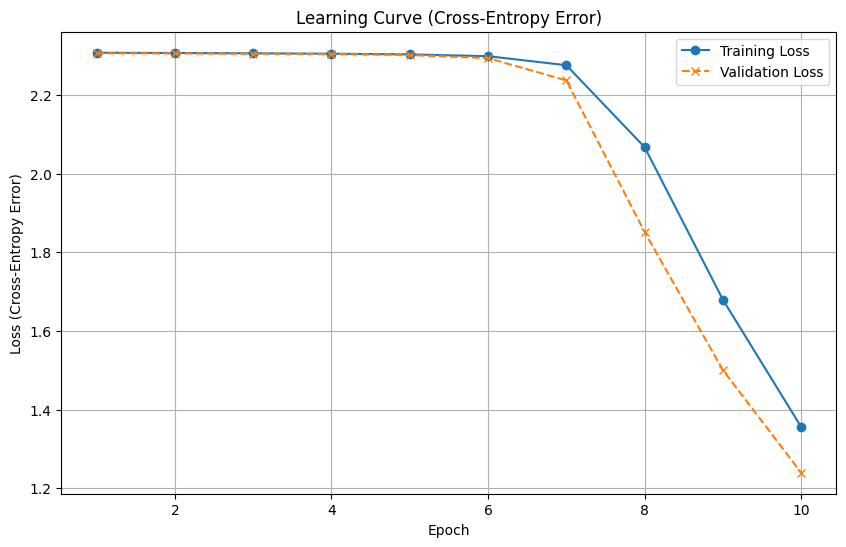

In [25]:
import matplotlib.pyplot as plt
import numpy as np

# Retrieve the recorded loss values
train_loss = nn_classifier.loss_history
val_loss = nn_classifier.val_loss_history
epochs = np.arange(1, nn_classifier.n_epoch + 1)

# Create the plot
plt.figure(figsize=(10, 6))
plt.plot(epochs, train_loss, label='Training Loss', marker='o', linestyle='-')
plt.plot(epochs, val_loss, label='Validation Loss', marker='x', linestyle='--')

# Add titles and labels
plt.title('Learning Curve (Cross-Entropy Error)')
plt.xlabel('Epoch')
plt.ylabel('Loss (Cross-Entropy Error)')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Problem 8 (Advance Assignment) Confirmation of Misclassification

Total Validation Samples: 12000
Validation Accuracy: 0.5332
Total Misclassified Samples: 5602


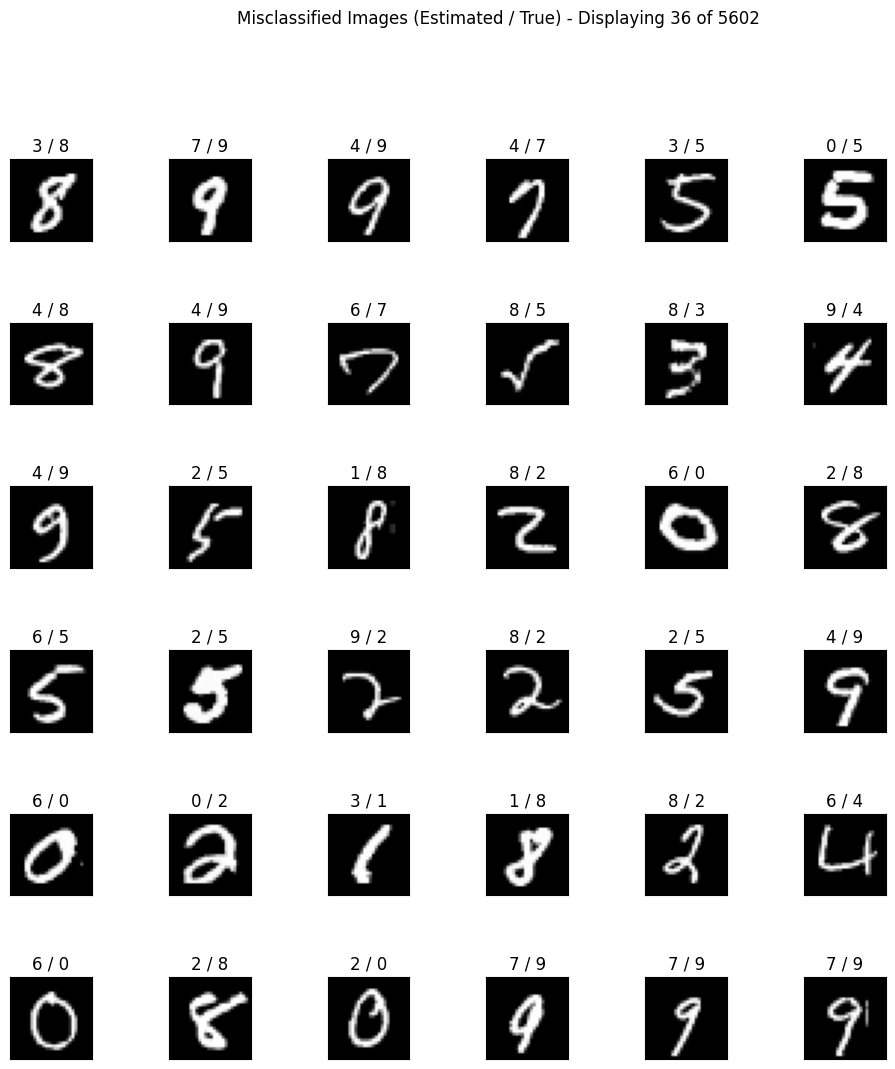

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

# --- PREREQUISITE STEPS (Must be run first) ---
# Assuming nn_classifier is trained, and X_val, y_val_one_hot are defined.
# If y_val is one-hot, convert it to integer labels:
y_val = np.argmax(y_val_one_hot, axis=1) 
y_pred = nn_classifier.predict(X_val)
# ---------------------------------------------


# The visualization code provided in the problem statement
print(f"Total Validation Samples: {X_val.shape[0]}")
print(f"Validation Accuracy: {accuracy_score(y_val, y_pred):.4f}")

num = 36  # How many misclassified images to display

# 1. Find indices where prediction (y_pred) does NOT equal true label (y_val)
true_false = y_pred == y_val
false_list = np.where(true_false == False)[0].astype(int) # Fixed np.int to int

print(f"Total Misclassified Samples: {false_list.shape[0]}")

if false_list.shape[0] < num:
    num = false_list.shape[0]
    
fig = plt.figure(figsize=(10, 10)) # Increased figure size for better visibility
fig.subplots_adjust(left=0, right=0.9, bottom=0, top=0.9, hspace=1.0, wspace=0.5)

# 2. Iterate and plot the misclassified images
for i in range(num):
    # Get the index of the i-th misclassified sample
    misclassified_index = false_list[i]
    
    ax = fig.add_subplot(6, 6, i + 1, xticks=[], yticks=[])
    
    # Title format: "estimated result / correct answer"
    ax.set_title("{} / {}".format(y_pred[misclassified_index], y_val[misclassified_index]))
    
    # Reshape the flattened 784-dimensional vector back to a 28x28 image for plotting
    image_28x28 = X_val[misclassified_index].reshape(28, 28)
    ax.imshow(image_28x28, cmap="gray")
    
plt.suptitle(f"Misclassified Images (Estimated / True) - Displaying {num} of {false_list.shape[0]}", y=1.05)
plt.show()